<h2 style="background-color: #4682B4; padding: 15px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;"> Pet Adoption Classifier</h2>


<div style="background-color: #f0f8ff; border-left: 6px solid #4682B4; padding: 10px; border-radius: 10px;">
    <h4 style="color: #1e90ff">📙 About the Dataset</h4>
    <p><strong>The Pet Adoption Dataset provides a comprehensive look into various factors that can influence the likelihood of a pet being adopted from a shelter. This dataset includes detailed information about pets available for adoption, covering various characteristics and attributes.</strong></p>
     <h3 style="color: #1e90ff">Features</h3>
    <p>PetID: Unique identifier for each pet.</p>  
    <p>PetType: Type of pet (e.g., Dog, Cat, Bird, Rabbit)</p>
    <p>Breed: Specific breed of the pet.</p>                                                       
    <p>AgeMonths: Age of the pet in months.</p>                                                       
    <p>Color: Color of the pet.</p>                                                       
    <p>Size: Size category of the pet (Small, Medium, Large).</p>                                                       
    <p>WeightKg: Weight of the pet in kilograms.</p>                                                       
    <p>Vaccinated: Vaccination status of the pet (0 - Not vaccinated, 1 - Vaccinated).</p>                                         <p>HealthCondition: Health condition of the pet (0 - Healthy, 1 - Medical condition)</p> 
    <p>TimeInShelterDays: Duration the pet has been in the shelter (days).</p>                                                       
    <p>AdoptionFee: Adoption fee charged for the pet (in dollars).</p>                                                       
    <p>PreviousOwner: Whether the pet had a previous owner (0 - No, 1 - Yes).</p>  
    <p>AdoptionLikelihood: Likelihood of the pet being adopted (0 - Unlikely, 1 - Likely).</p>                                                       
    
</div>


<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Libraries</h2>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
# Machine learning Algorithms 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, recall_score, classification_report
# Neural Network
import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

2025-05-01 07:07:17.226581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746083237.478538      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746083237.552697      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df  = pd.read_csv('/kaggle/input/predict-pet-adoption-status-dataset/pet_adoption_data.csv')
df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [3]:
df.shape

(2007, 13)

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;"> Check Null Values</h2>


In [4]:
df.isna().sum()

PetID                 0
PetType               0
Breed                 0
AgeMonths             0
Color                 0
Size                  0
WeightKg              0
Vaccinated            0
HealthCondition       0
TimeInShelterDays     0
AdoptionFee           0
PreviousOwner         0
AdoptionLikelihood    0
dtype: int64

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;"> Check Duplicates Values</h2>


In [5]:
df.duplicated().sum()

0


<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;"> Data Summarize, Check Statistical Summary, Correlation</h2>


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


In [7]:
df.describe()

,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,1503.000000,92.279522,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,52.148363,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,1.000000,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,48.000000,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,94.000000,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,138.000000,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000
max,2506.000000,179.000000,29.995628,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


In [8]:
df.corr(numeric_only=True)

,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
PetID,1.000000,-0.008464,0.034315,0.008808,0.010486,0.017683,0.010557,0.001339,0.049582
AgeMonths,-0.008464,1.000000,-0.029189,-0.001801,0.017200,0.036837,-0.038129,0.034943,-0.202209
WeightKg,0.034315,-0.029189,1.000000,0.022526,0.000708,-0.000980,-0.002367,-0.049155,0.017601
Vaccinated,0.008808,-0.001801,0.022526,1.000000,0.024079,-0.001123,0.021662,-0.011460,0.301311
HealthCondition,0.010486,0.017200,0.000708,0.024079,1.000000,-0.012664,-0.002537,0.013755,-0.244061
TimeInShelterDays,0.017683,0.036837,-0.000980,-0.001123,-0.012664,1.000000,-0.007104,0.007958,0.008867
AdoptionFee,0.010557,-0.038129,-0.002367,0.021662,-0.002537,-0.007104,1.000000,0.009755,-0.005486
PreviousOwner,0.001339,0.034943,-0.049155,-0.011460,0.013755,0.007958,0.009755,1.000000,-0.023065
AdoptionLikelihood,0.049582,-0.202209,0.017601,0.301311,-0.244061,0.008867,-0.005486,-0.023065,1.000000


<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;"> EDA</h2>


- Exploratory Data Analysis (Data Visualization)

In [9]:
df['AdoptionLikelihood'].value_counts()

AdoptionLikelihood
0    1348
1     659
Name: count, dtype: int64

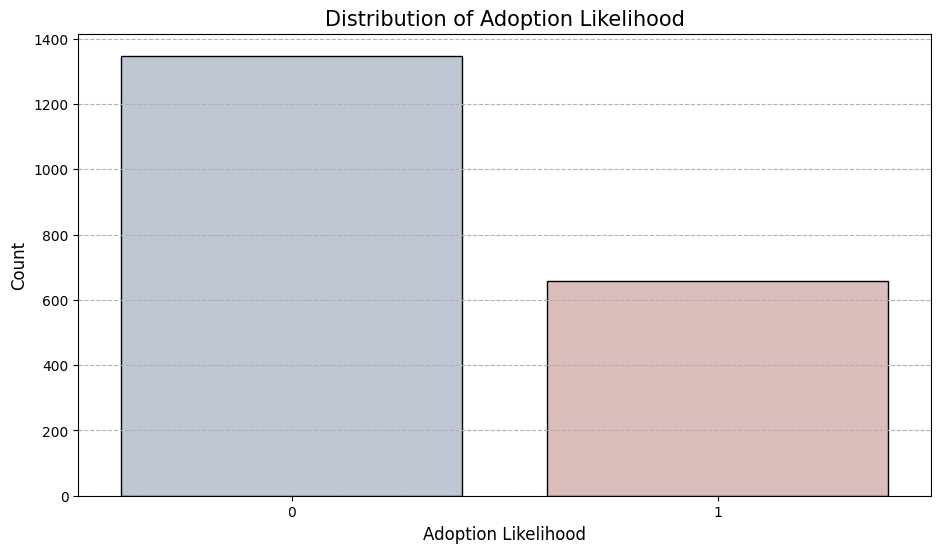

In [10]:
plt.figure(figsize=(11,6))
sns.countplot(x=df['AdoptionLikelihood'],palette='vlag', edgecolor='black')
plt.title('Distribution of Adoption Likelihood', fontsize=15)
plt.xlabel('Adoption Likelihood', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()


In [11]:
df['PetType'].value_counts()

PetType
Dog       522
Cat       505
Rabbit    493
Bird      487
Name: count, dtype: int64

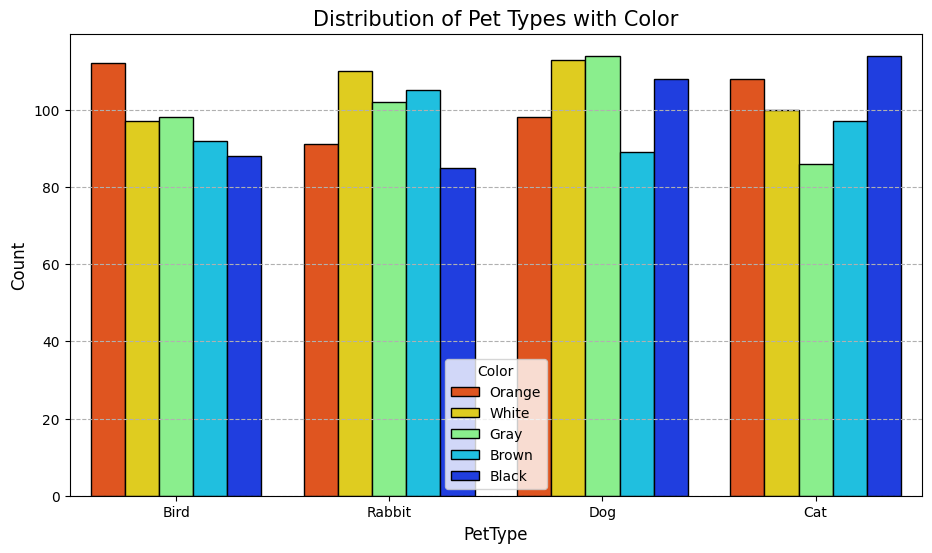

In [12]:
plt.figure(figsize=(11,6))
sns.countplot(x=df['PetType'],palette='jet_r', edgecolor='black', hue=df['Color'])
plt.title('Distribution of Pet Types with Color', fontsize=15)
plt.xlabel('PetType', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()


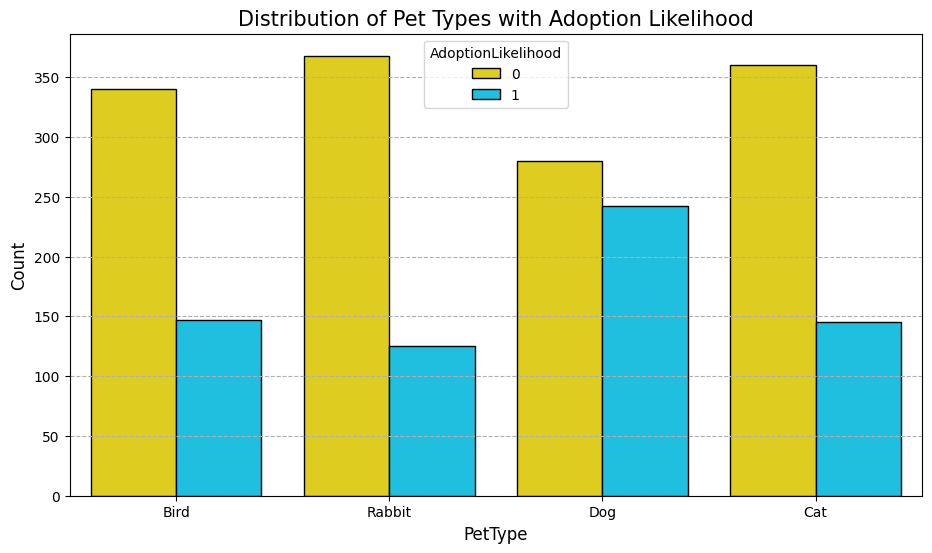

In [13]:
plt.figure(figsize=(11,6))
sns.countplot(x=df['PetType'],palette='jet_r', edgecolor='black', hue=df['AdoptionLikelihood'])
plt.title('Distribution of Pet Types with Adoption Likelihood', fontsize=15)
plt.xlabel('PetType', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()


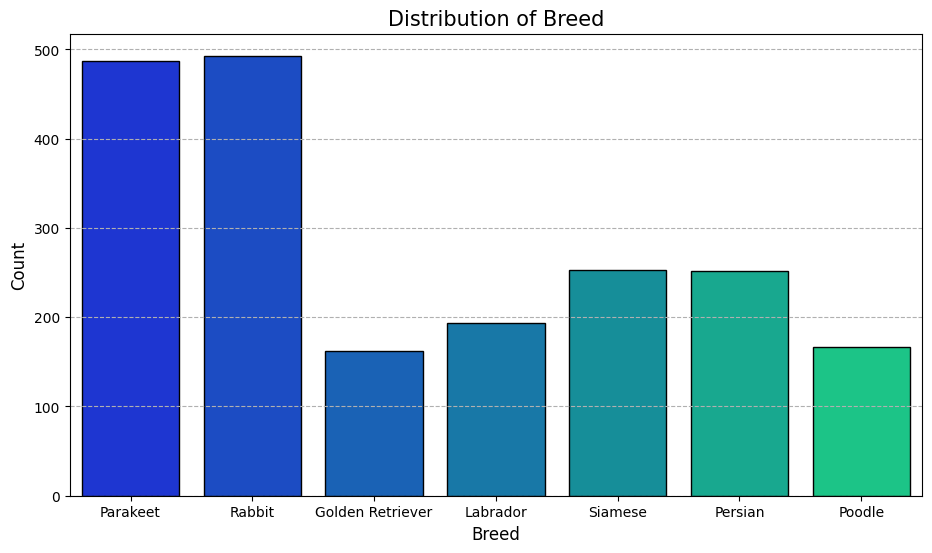

In [14]:
plt.figure(figsize=(11,6))
sns.countplot(x=df['Breed'],palette='winter', edgecolor='black')
plt.title('Distribution of Breed', fontsize=15)
plt.xlabel('Breed', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()


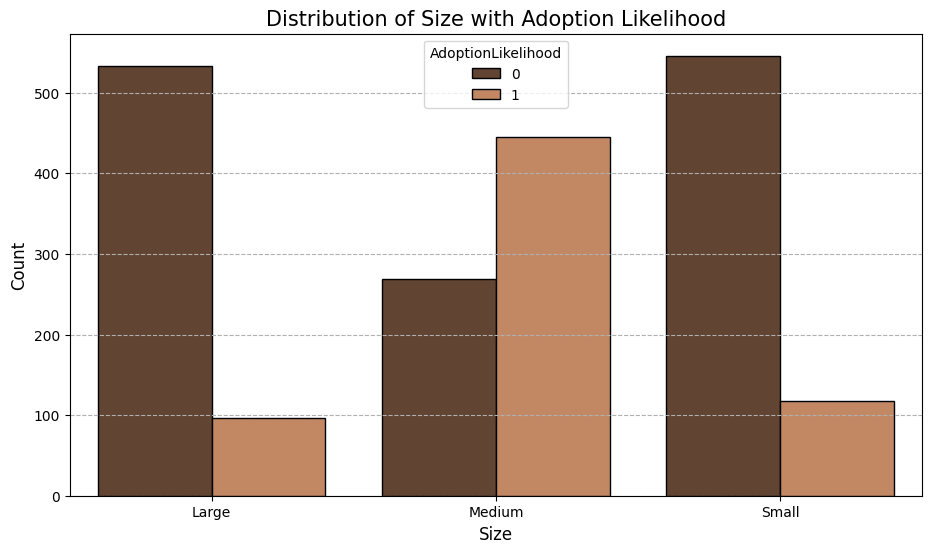

In [15]:
plt.figure(figsize=(11,6))
sns.countplot(x=df['Size'],palette='copper', edgecolor='black', hue=df['AdoptionLikelihood'])
plt.title('Distribution of Size with Adoption Likelihood', fontsize=15)
plt.xlabel('Size', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()


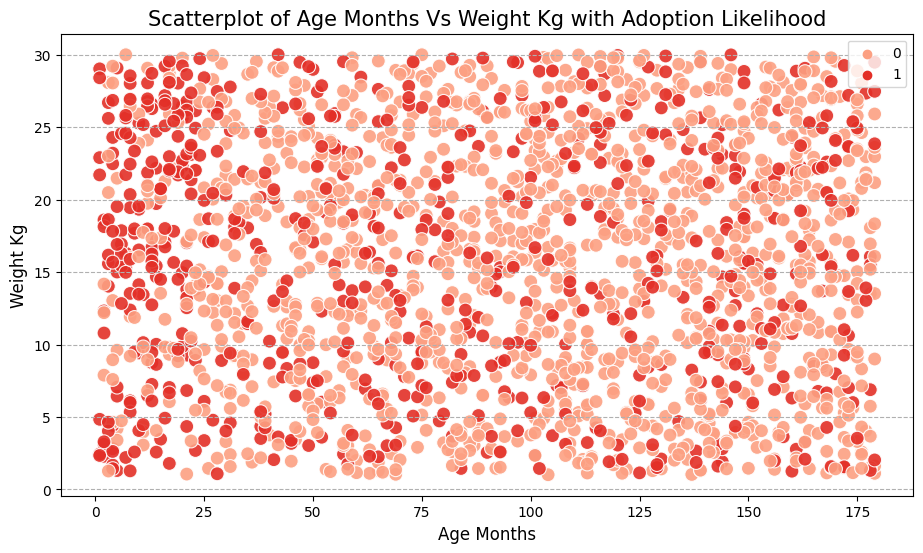

In [16]:
plt.figure(figsize=(11,6))
sns.scatterplot(x=df['AgeMonths'], y=df['WeightKg'], s=100, alpha=0.9, hue=df['AdoptionLikelihood'], palette='Reds')
plt.title('Scatterplot of Age Months Vs Weight Kg with Adoption Likelihood', fontsize=15)
plt.xlabel('Age Months', fontsize=12)
plt.ylabel('Weight Kg', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()


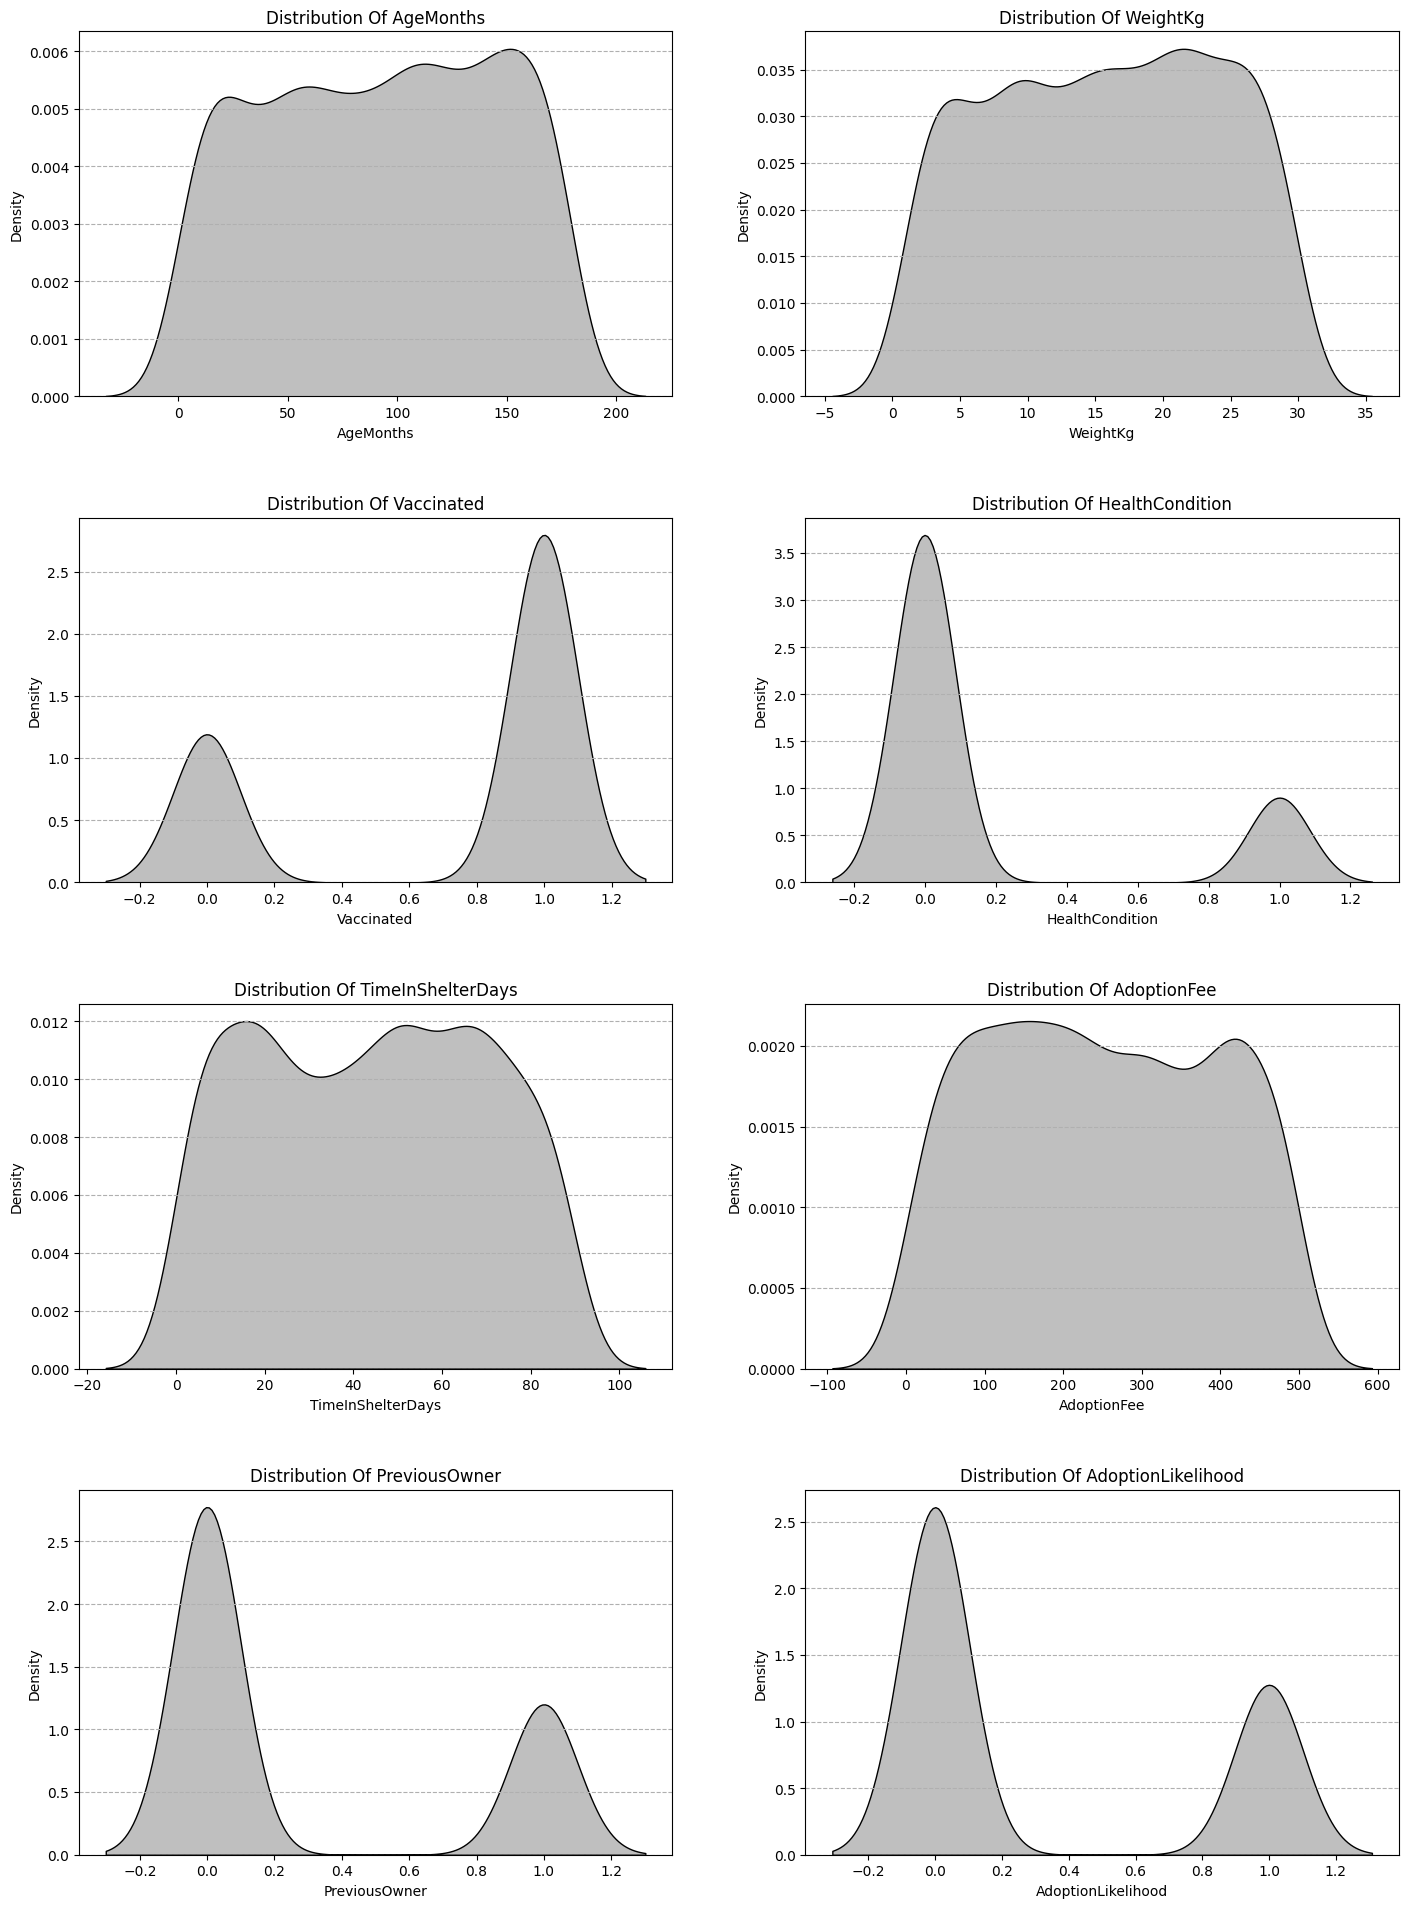

In [17]:
plt.figure(figsize=(15,20))
for c, cols in enumerate(['AgeMonths','WeightKg',
       'Vaccinated', 'HealthCondition', 'TimeInShelterDays', 'AdoptionFee',
       'PreviousOwner', 'AdoptionLikelihood']):
    plt.subplot(4, 2, c+1)
    sns.kdeplot(x=cols, data=df, color='black', shade=True)
    plt.title(f"Distribution Of {cols}")
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout(pad=4.0)
    
plt.show()

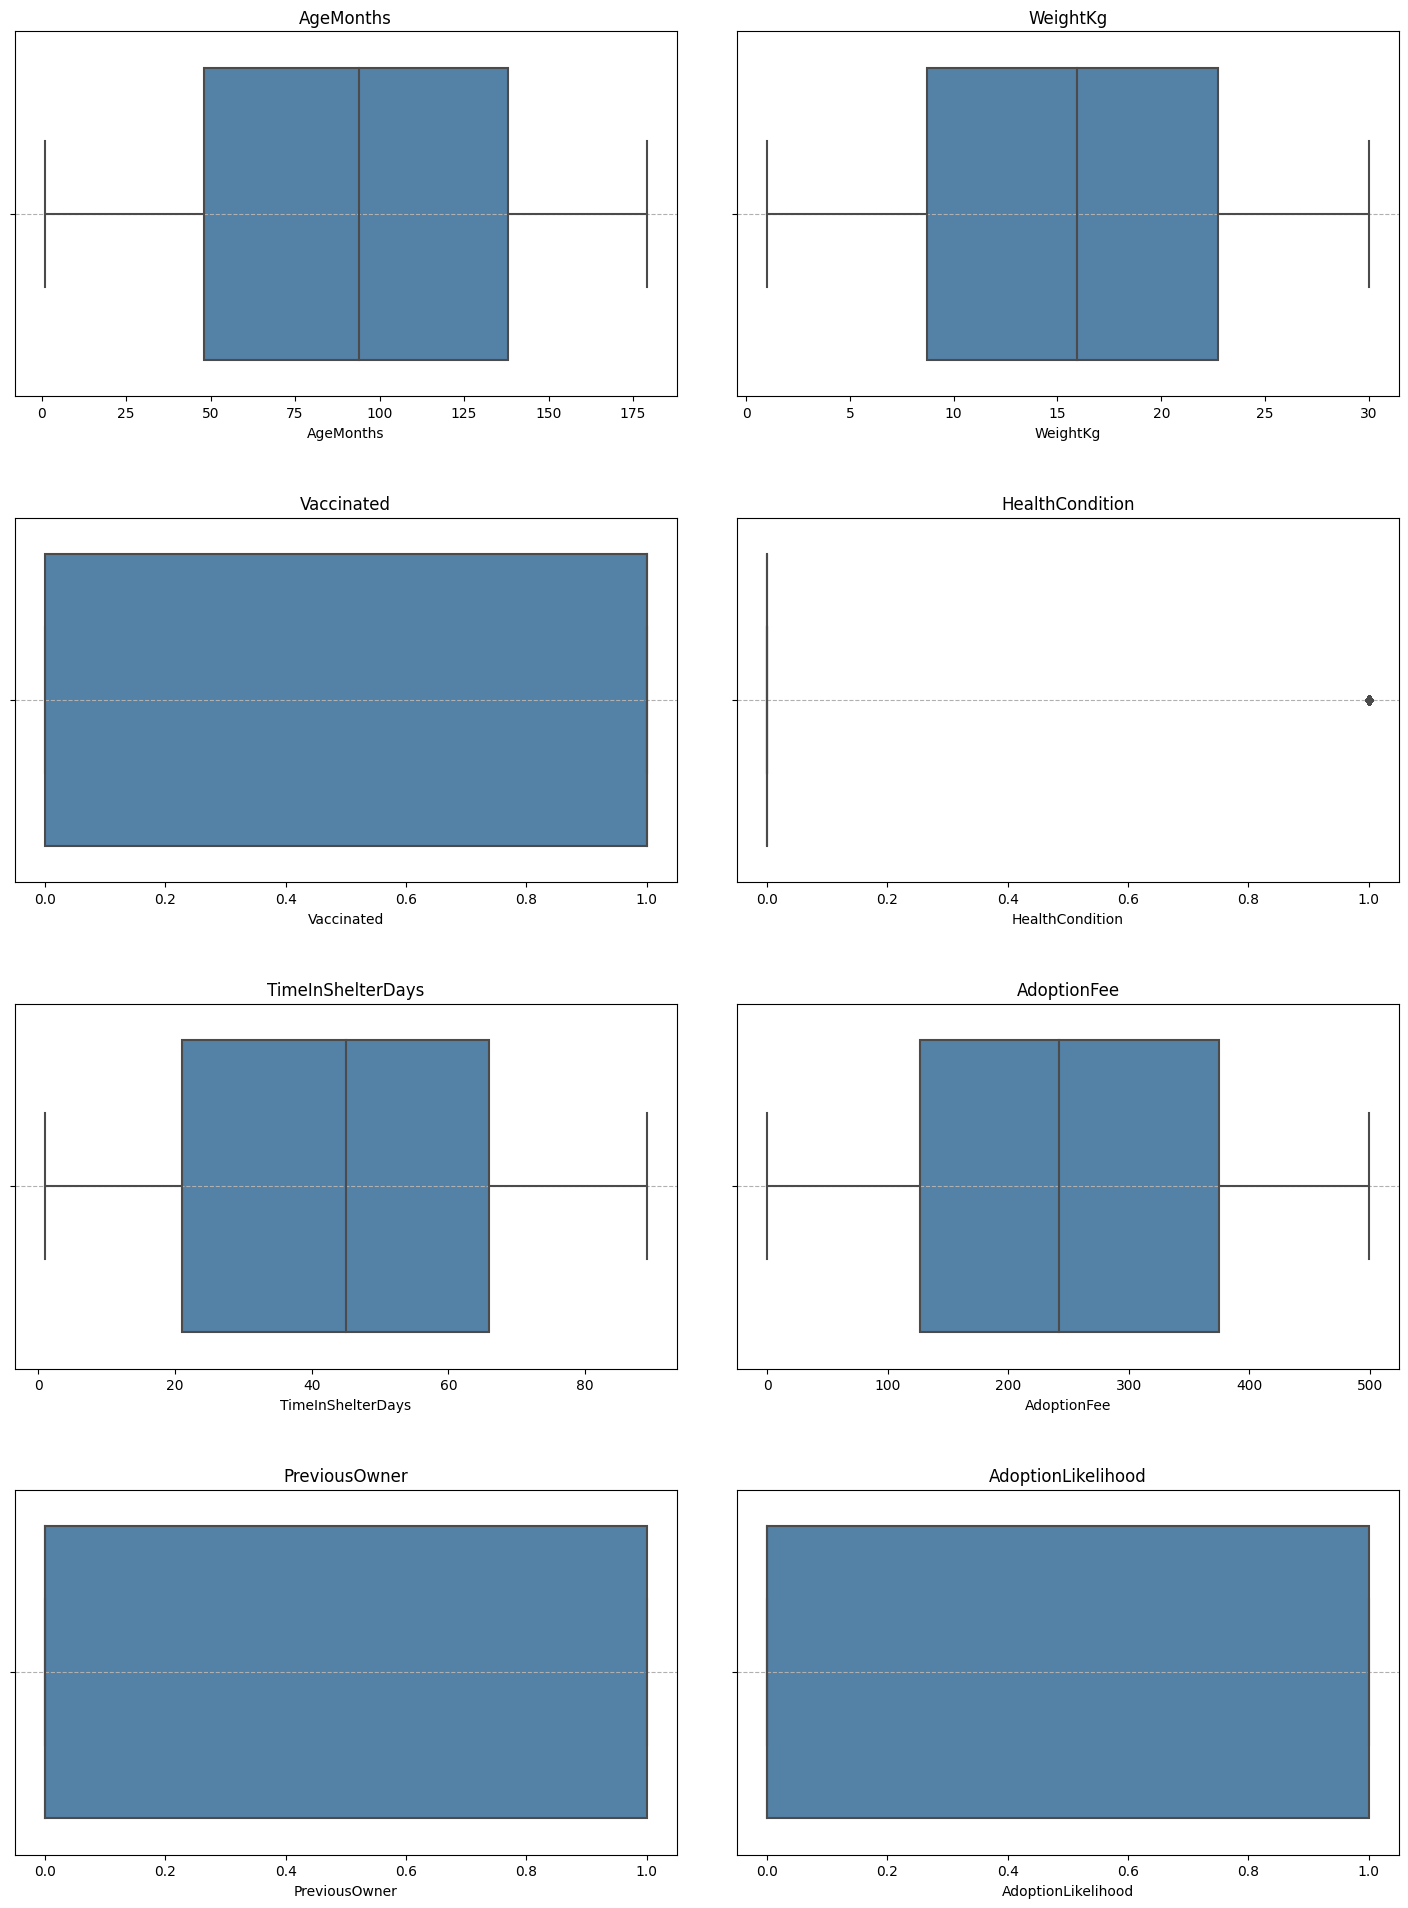

In [18]:
plt.figure(figsize=(15,20))
for c, cols in enumerate(['AgeMonths','WeightKg',
       'Vaccinated', 'HealthCondition', 'TimeInShelterDays', 'AdoptionFee',
       'PreviousOwner', 'AdoptionLikelihood']):
    plt.subplot(4, 2, c+1)
    sns.boxplot(x=cols, data=df, color='steelblue')
    plt.title(f"{cols}")
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout(pad=4.0)
    
plt.show()

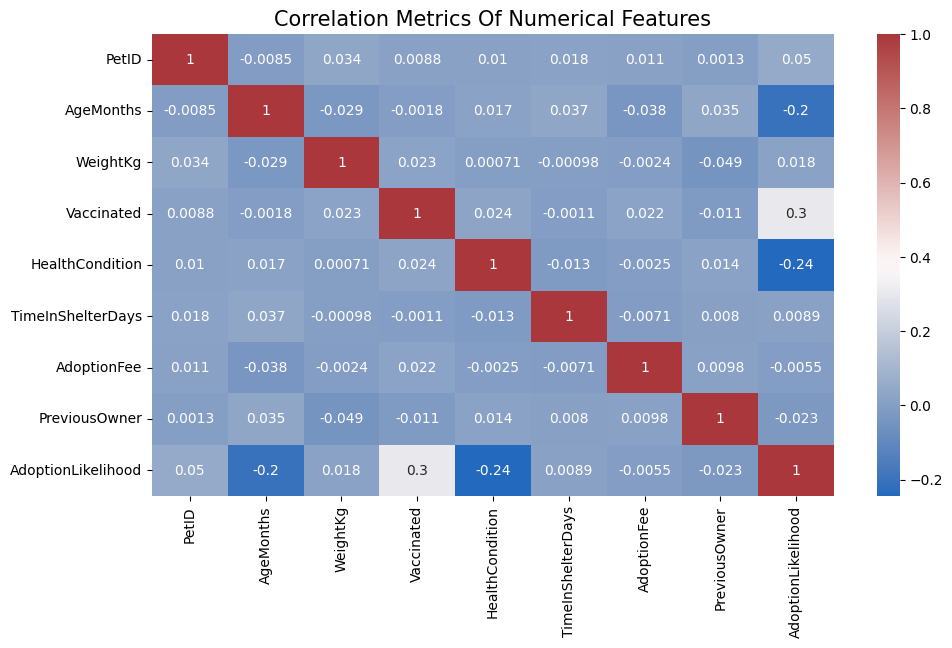

In [19]:
plt.figure(figsize=(11,6))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='vlag')
plt.title('Correlation Metrics Of Numerical Features', fontsize=15)

plt.show()

In [20]:
X = df[['PetType', 'Breed', 'AgeMonths', 'Color', 'Size', 'WeightKg',
       'Vaccinated', 'HealthCondition', 'TimeInShelterDays', 'AdoptionFee','PreviousOwner']]
y = df['AdoptionLikelihood']

X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.3)
print(f"X_train Shape: {X_train.shape}")
print(f"Y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (1404, 11)
Y_train Shape: (1404,)
X_test Shape: (603, 11)
y_test Shape: (603,)


<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Encoding Categorical Features</h2>



In [21]:
transformer = ColumnTransformer(transformers=[
    ('tran1', OneHotEncoder(sparse=False, drop='first',), ['PetType', 'Breed', 'Color']),
    ('tran2', OrdinalEncoder(categories=[['Small', 'Medium', 'Large']]), ['Size'])
], remainder='passthrough')

In [22]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.fit_transform(X_test)

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Feature Scaling</h2>



In [23]:
scaler = StandardScaler()
scaler.fit(X_train_transformed, X_test_transformed)
X_train_transformed_scaled = scaler.transform(X_train_transformed)
X_test_transformed_scaled = scaler.transform(X_test_transformed)

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Machine Learning Models</h2>



In [24]:
classification_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    'XGBoost Classifier': XGBClassifier()
}


Name: Logistic Regression
Accuracy: 0.75
Precision Score: 0.6666666666666666


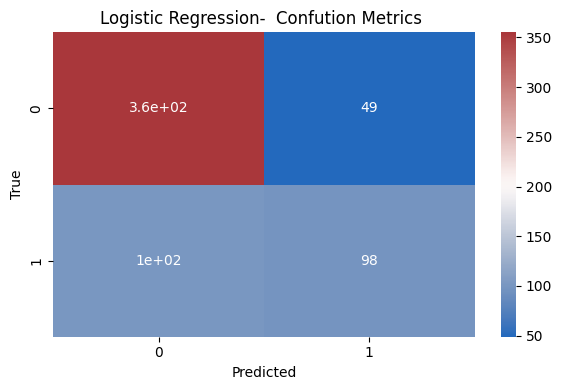


Name: Random Forest Classifier
Accuracy: 0.91
Precision Score: 0.9393939393939394


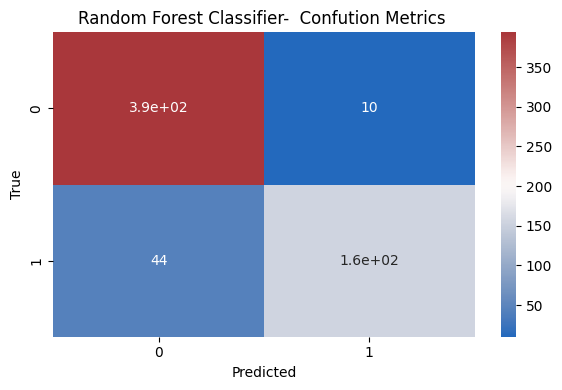


Name: Gradient Boosting Classifier
Accuracy: 0.92
Precision Score: 0.9116022099447514


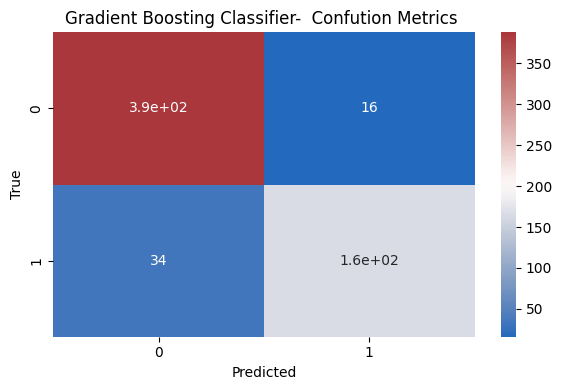


Name: Naive Bayes
Accuracy: 0.77
Precision Score: 0.6746987951807228


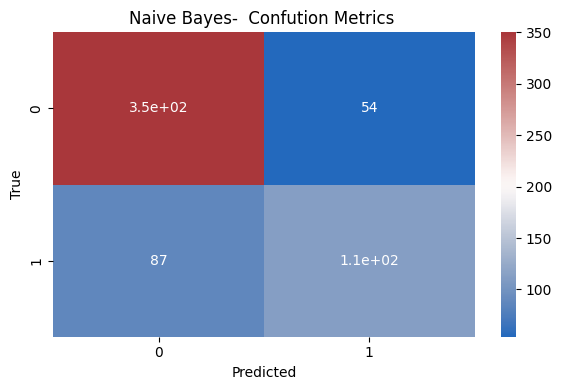


Name: Decision Tree Classifier
Accuracy: 0.85
Precision Score: 0.7707317073170732


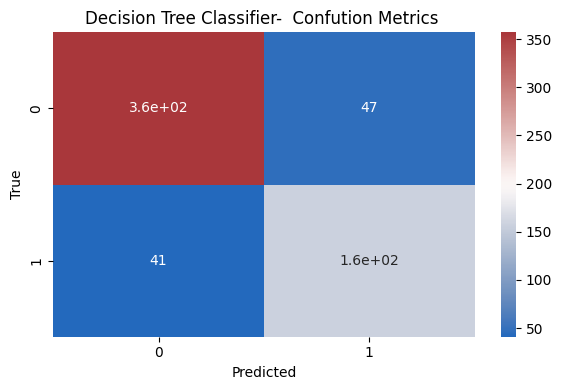


Name: XGBoost Classifier
Accuracy: 0.91
Precision Score: 0.9152542372881356


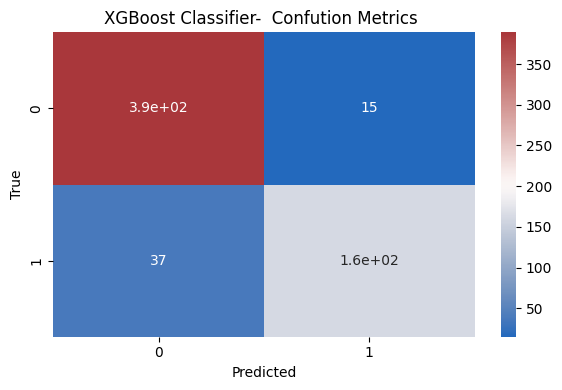


Summary:


,Model Name,Test Accuracy,Test Precision,Test Recall Score,Test F1 Score
0,Logistic Regression,0.751244,0.666667,0.685588,0.696028
1,Random Forest Classifier,0.910448,0.939394,0.877071,0.893758
2,Gradient Boosting Classifier,0.917081,0.911602,0.894771,0.903944
3,Naive Bayes,0.766169,0.674699,0.714575,0.723021
4,Decision Tree Classifier,0.854063,0.770732,0.838817,0.836226
5,XGBoost Classifier,0.913765,0.915254,0.888471,0.899526


In [25]:
summary = []
for names, model in classification_models.items():
    model.fit(X_train_transformed_scaled, y_train)
    preds = model.predict(X_test_transformed_scaled)
    accuracy = accuracy_score(y_test, preds)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds, average='macro')
    f = f1_score(y_test, preds,  average='macro')
    print(f"\nName: {names}")
    print(f"Accuracy: {accuracy:.2f}")   
    print(f"Precision Score: {p}")
    
    plt.figure(figsize=(6, 4))
    cm  = confusion_matrix(y_test,preds)
    sns.heatmap(cm, annot=True, cmap='vlag')
    plt.title(f"{names}-  Confution Metrics ")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    
    summary.append({
        'Model Name': names,
        'Test Accuracy': accuracy,
        'Test Precision': p,
        'Test Recall Score': r,
        'Test F1 Score': f
        
    })
    summary_df = pd.DataFrame(summary)

# Show all model evaluation metrics in one table
print("\nSummary:")
summary_df


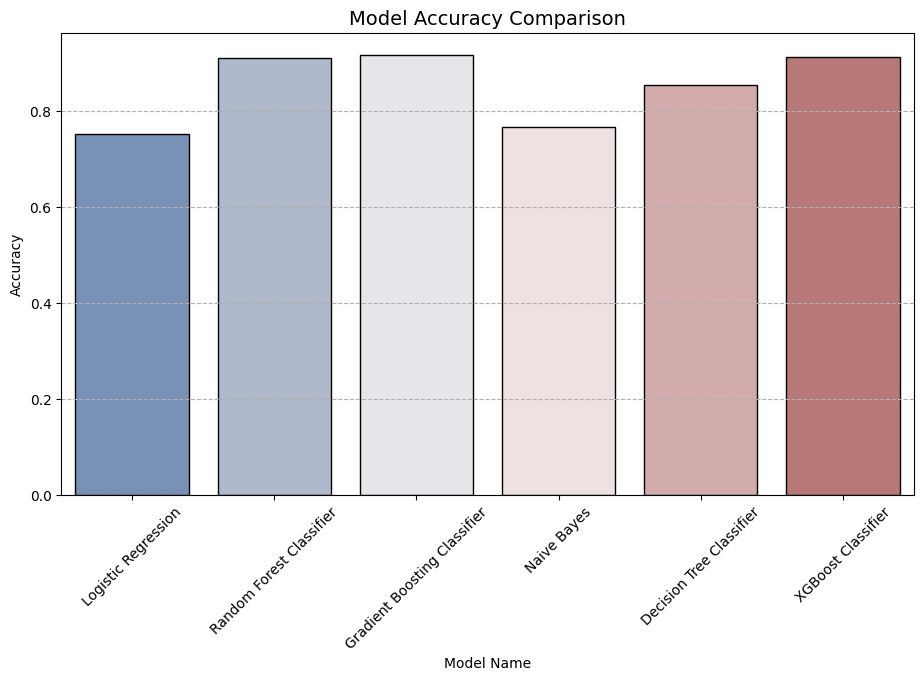

In [26]:
plt.figure(figsize=(11, 6))
sns.barplot(data=summary_df, x='Model Name', y='Test Accuracy', palette='vlag', edgecolor='black')
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Model Name")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Neural Networks (ANN)</h2>


In [27]:
model = Sequential()
model.add(Dense(20, activation='relu', input_dim=21))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


2025-05-01 07:07:41.551851: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │             440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 20)                  │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           1,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │           1,020 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,611 (10.20 KB)

 Trainable params: 2,571 (10.04 KB)

 Non-trainable params: 40 (160.00 B)

In [29]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, )

In [30]:
history = model.fit(X_train_transformed_scaled, y_train, validation_data=(X_test_transformed_scaled, y_test), 
                    epochs=100, callbacks=callback)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5353 - loss: 0.7225 - val_accuracy: 0.6700 - val_loss: 0.6251
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6806 - loss: 0.6170 - val_accuracy: 0.6766 - val_loss: 0.6011
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6740 - loss: 0.5932 - val_accuracy: 0.6965 - val_loss: 0.5841
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7108 - loss: 0.5655 - val_accuracy: 0.7181 - val_loss: 0.5700
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7057 - loss: 0.5487 - val_accuracy: 0.7280 - val_loss: 0.5556
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7010 - loss: 0.5475 - val_accuracy: 0.7396 - val_loss: 0.5448
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7199 - loss: 0.5264 - val_accuracy: 0.7463 - val_loss: 0.5376
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7536 - loss: 0.5042 - val_accuracy: 0.7496 - v

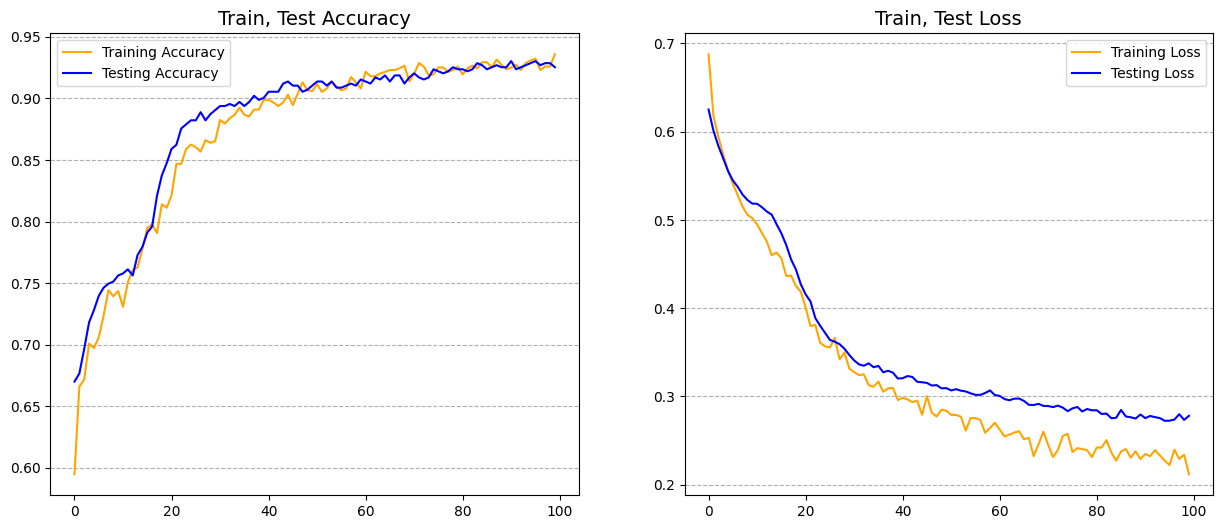

In [31]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title('Train, Test Accuracy', fontsize=14)
plt.plot(history.history['accuracy'], color='orange', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Testing Accuracy')
plt.legend()
plt.grid(axis='y', linestyle='--')


plt.subplot(1,2,2)
plt.title('Train, Test Loss', fontsize=14)
plt.plot(history.history['loss'], color='orange', label='Training Loss')
plt.plot(history.history['val_loss'], color='blue', label='Testing Loss')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

<h2 style="background-color: #4682B4; padding: 10px 20px; border-radius: 20px; color: white; height: 30px; display: flex; align-items: center;">Model Evaluation</h2>



In [32]:
test_loss, test_accuracy = model.evaluate(X_test_transformed_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.2f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9253 - loss: 0.2772 
Test Accuracy: 0.93
Test Loss: 0.27


In [33]:
y_pred = model.predict(X_test_transformed_scaled)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [34]:
y_pred=y_pred.round().astype(int)


In [35]:
print('classification report :\n', classification_report(y_test,y_pred))

classification report :
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       404
           1       0.93      0.84      0.89       199

    accuracy                           0.93       603
   macro avg       0.93      0.91      0.92       603
weighted avg       0.93      0.93      0.93       603



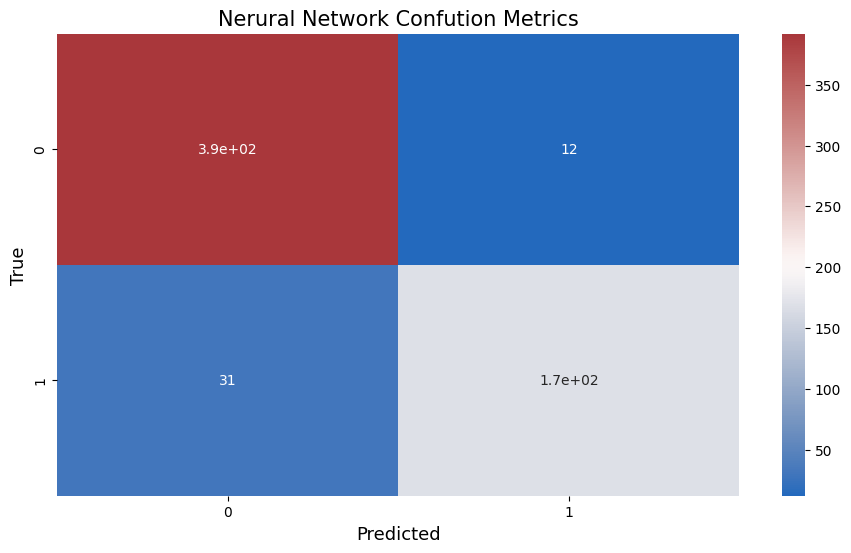

In [36]:
conf_m = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11,6))
sns.heatmap(conf_m,annot=True, cmap='vlag')
plt.title('Nerural Network Confution Metrics', fontsize=15)
plt.xlabel('Predicted',fontsize=13)
plt.ylabel('True',fontsize=13)

plt.show()

<div style="background-color: #f0f8ff; border-left: 6px solid #4682B4; padding: 10px; border-radius: 10px;"> 
    <p><strong>If you found this notebook helpful, please consider giving it an upvote!👍                           
    Your support motivates me to create more useful content like this, and it helps others discover the notebook too! 🙌

Thank you for your time, and I hope this notebook brings value to your data science journey!😊</strong></p>
</div>
